# Intelligent Customer Contact Optimization System

**Pipeline stages**

1. Data Understanding & Quality Assessment
2. Statistical Validation & Business Hypothesis Testing
3. Feature Engineering
4. Customer Segmentation & Persona Discovery
5. Synthetic Campaign History Generation
6. Best Time-to-Call Model
7. Look-Alike Model (Cold Start)
8. Channel Affinity & Response Propensity Models
9. Executive Business Report

## 0. Setup

In [2]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from scipy import stats
from scipy.stats import chi2_contingency, mannwhitneyu, ttest_ind, shapiro, zscore

from sklearn.preprocessing import LabelEncoder, RobustScaler, OneHotEncoder
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from sklearn.metrics import (silhouette_score, classification_report, accuracy_score,
                              f1_score, roc_auc_score)
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from scipy.cluster.hierarchy import linkage, dendrogram

# Optional heavy dependencies - imported defensively so the notebook can still be
# read/authored in environments where they are not installed.
try:
    from xgboost import XGBClassifier
    HAS_XGB = True
except ImportError:
    HAS_XGB = False
    print("xgboost not installed - XGBoost cells will be skipped at runtime.")

try:
    import lightgbm as lgb
    HAS_LGB = True
except ImportError:
    HAS_LGB = False
    print("lightgbm not installed - LightGBM cells will be skipped at runtime.")

try:
    import statsmodels.api as sm
    from statsmodels.stats.multitest import multipletests
    from statsmodels.stats.outliers_influence import variance_inflation_factor
    HAS_SM = True
except ImportError:
    HAS_SM = False
    print("statsmodels not installed - VIF/multiple-testing cells will be skipped at runtime.")

pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 100)
plt.style.use("ggplot")

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

In [3]:
def fit_xgb_multiclass(X_train, y_train, **xgb_kwargs):
    """Fit an XGBClassifier on possibly-non-numeric multiclass labels.

    XGBoost's sklearn API expects integer targets in [0, num_class) for
    multiclass objectives. This helper label-encodes y before fitting and
    returns both the fitted model and the encoder needed to invert
    predictions back to the original class names.
    """
    le = LabelEncoder()
    y_enc = le.fit_transform(y_train)
    model = XGBClassifier(
        objective="multi:softprob",
        num_class=len(le.classes_),
        eval_metric="mlogloss",
        random_state=RANDOM_STATE,
        **xgb_kwargs,
    )
    model.fit(X_train, y_enc)
    return model, le


def predict_xgb_multiclass(model, le, X):
    """Predict with a model trained via fit_xgb_multiclass and decode labels back."""
    return le.inverse_transform(model.predict(X))

## 1. Data Understanding & Quality Assessment

Objectives: understand the structure of the dataset, assess data quality, detect
missing values/duplicates, explore demographics and campaign outcomes, and identify
potential data leakage before feature engineering begins.

In [4]:
df = pd.read_csv("bank-full.csv", sep=";")
print(f"Rows: {df.shape[0]:,}")
print(f"Columns: {df.shape[1]}")
df.info()
df.sample(10)

Rows: 45,211
Columns: 17
<class 'pandas.DataFrame'>
RangeIndex: 45211 entries, 0 to 45210
Data columns (total 17 columns):
 #   Column     Non-Null Count  Dtype
---  ------     --------------  -----
 0   age        45211 non-null  int64
 1   job        45211 non-null  str  
 2   marital    45211 non-null  str  
 3   education  45211 non-null  str  
 4   default    45211 non-null  str  
 5   balance    45211 non-null  int64
 6   housing    45211 non-null  str  
 7   loan       45211 non-null  str  
 8   contact    45211 non-null  str  
 9   day        45211 non-null  int64
 10  month      45211 non-null  str  
 11  duration   45211 non-null  int64
 12  campaign   45211 non-null  int64
 13  pdays      45211 non-null  int64
 14  previous   45211 non-null  int64
 15  poutcome   45211 non-null  str  
 16  y          45211 non-null  str  
dtypes: int64(7), str(10)
memory usage: 5.9 MB


,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,y
3776,40,blue-collar,married,secondary,no,580,yes,no,unknown,16,may,192,1,-1,0,unknown,no
9928,47,services,single,secondary,no,3644,no,no,unknown,9,jun,83,2,-1,0,unknown,no
33409,25,student,single,tertiary,no,538,yes,no,cellular,20,apr,226,1,-1,0,unknown,no
31885,42,management,married,tertiary,no,1773,no,no,cellular,9,apr,311,1,336,1,failure,no
15738,56,management,married,tertiary,no,217,no,yes,cellular,21,jul,121,2,-1,0,unknown,no
30813,28,blue-collar,married,secondary,no,1134,no,no,cellular,9,feb,130,3,-1,0,unknown,no
35463,24,management,single,tertiary,no,1085,no,yes,cellular,7,may,95,6,-1,0,unknown,no
31382,37,admin.,single,secondary,no,127,no,no,cellular,23,mar,83,4,-1,0,unknown,no
16904,30,blue-collar,single,secondary,no,3,yes,no,cellular,25,jul,51,1,-1,0,unknown,no
11930,38,technician,single,secondary,no,258,no,yes,unknown,20,jun,587,2,-1,0,unknown,no


In [5]:
data_dictionary = pd.DataFrame({
    "Feature": ["age","job","marital","education","default","balance","housing","loan",
                "contact","day","month","duration","campaign","pdays","previous","poutcome","y"],
    "Description": [
        "Customer age","Occupation","Marital status","Education","Credit default",
        "Average yearly balance","Housing loan","Personal loan","Contact type",
        "Last contact day","Last contact month","Last call duration (seconds)",
        "Number of contacts in this campaign","Days since previous contact",
        "Number of previous contacts","Previous campaign outcome","Campaign response"
    ]
})
data_dictionary

,Feature,Description
0,age,Customer age
1,job,Occupation
2,marital,Marital status
3,education,Education
4,default,Credit default
5,balance,Average yearly balance
6,housing,Housing loan
7,loan,Personal loan
8,contact,Contact type
9,day,Last contact day


In [6]:
missing = pd.DataFrame(df.isnull().sum(), columns=["Missing"])
missing["Percentage"] = missing["Missing"] / len(df) * 100
display(missing.sort_values("Percentage", ascending=False))

duplicates = df.duplicated().sum()
print(f"Duplicate Rows: {duplicates}")
df = df.drop_duplicates()

df.describe().T

,Missing,Percentage
age,0,0.0
job,0,0.0
marital,0,0.0
education,0,0.0
default,0,0.0
balance,0,0.0
housing,0,0.0
loan,0,0.0
contact,0,0.0
day,0,0.0


Duplicate Rows: 0


,count,mean,std,min,25%,50%,75%,max
age,45211.0,40.936210,10.618762,18.0,33.0,39.0,48.0,95.0
balance,45211.0,1362.272058,3044.765829,-8019.0,72.0,448.0,1428.0,102127.0
day,45211.0,15.806419,8.322476,1.0,8.0,16.0,21.0,31.0
duration,45211.0,258.163080,257.527812,0.0,103.0,180.0,319.0,4918.0
campaign,45211.0,2.763841,3.098021,1.0,1.0,2.0,3.0,63.0
pdays,45211.0,40.197828,100.128746,-1.0,-1.0,-1.0,-1.0,871.0
previous,45211.0,0.580323,2.303441,0.0,0.0,0.0,0.0,275.0


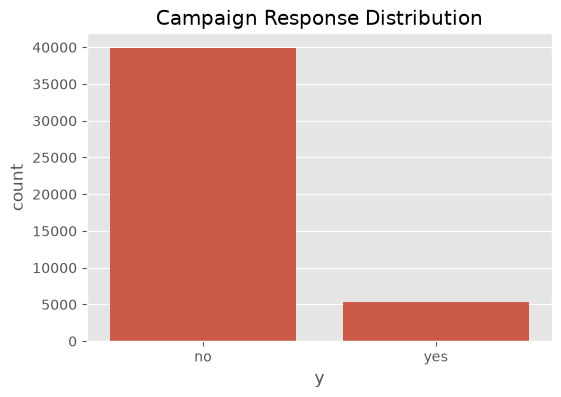

y
no     88.30152
yes    11.69848
Name: proportion, dtype: float64

In [7]:
plt.figure(figsize=(6,4))
sns.countplot(data=df, x="y")
plt.title("Campaign Response Distribution")
plt.show()

response_rate = df["y"].value_counts(normalize=True) * 100
response_rate

**Business Insight:** the response variable is highly imbalanced — most customers do
not subscribe to the offered product, consistent with typical marketing conversion rates
below 20%. This imbalance is handled downstream via macro-F1 / ROC-AUC evaluation rather
than raw accuracy.

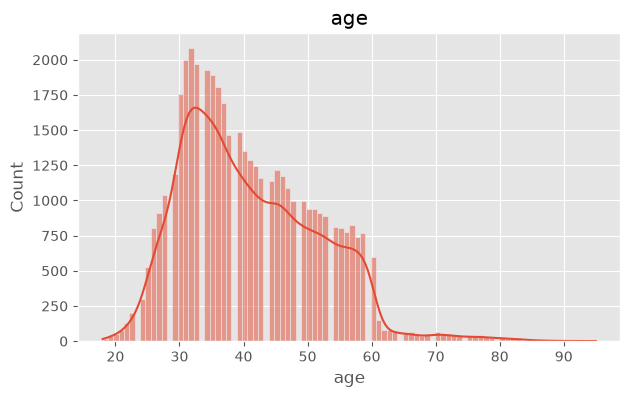

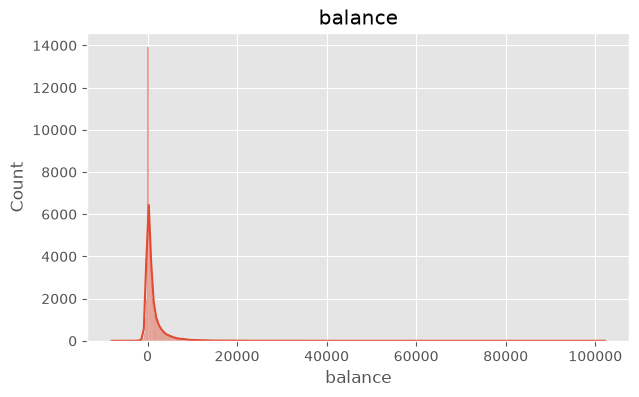

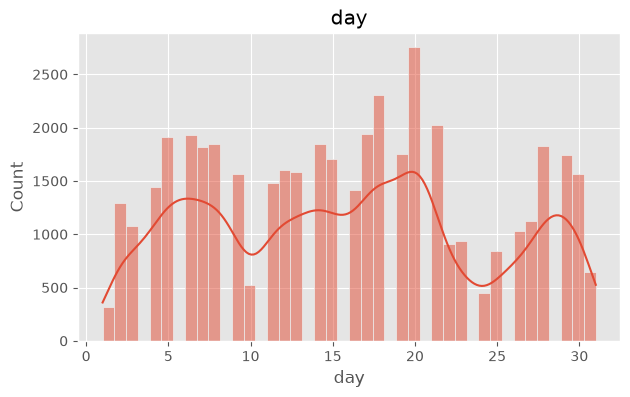

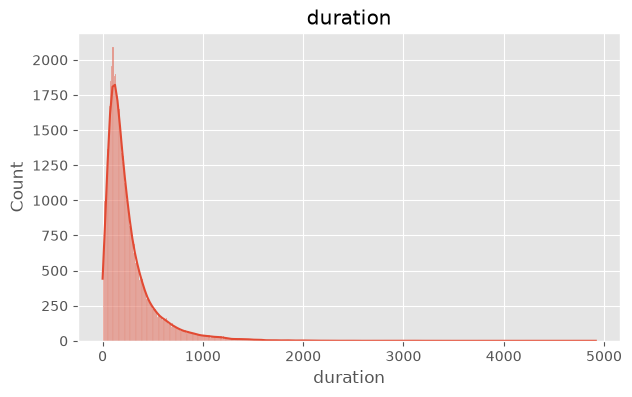

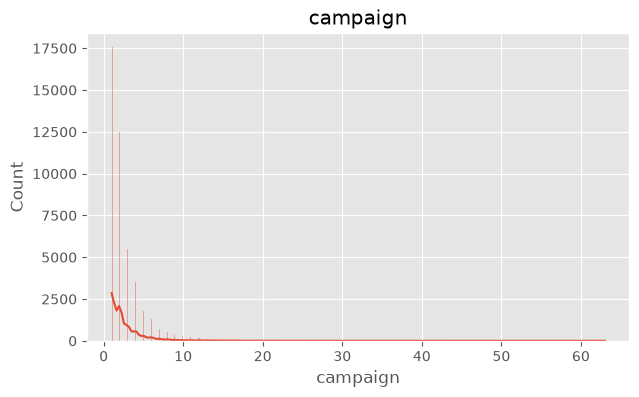

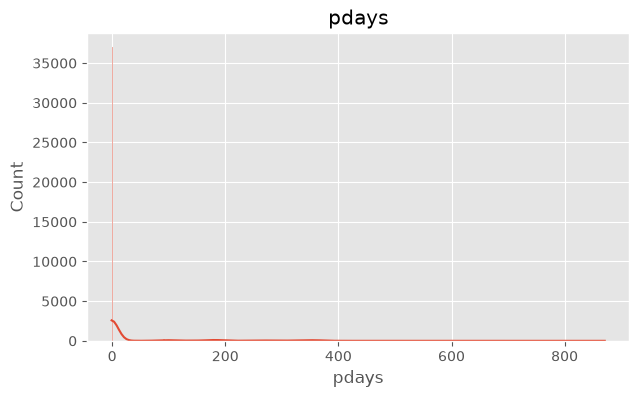

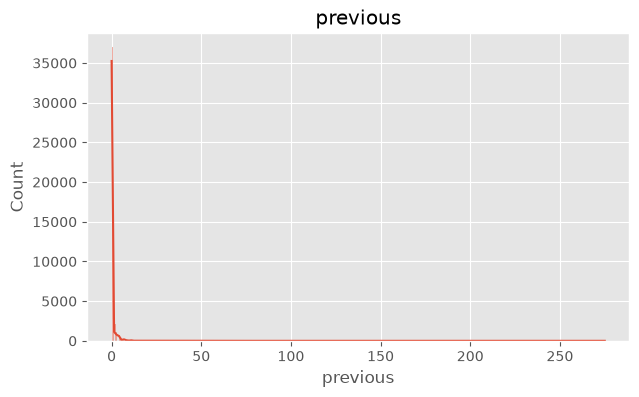

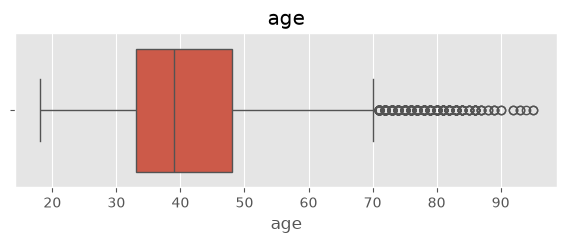

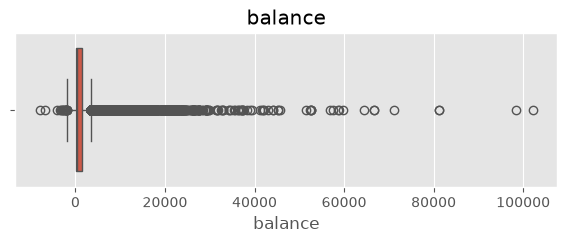

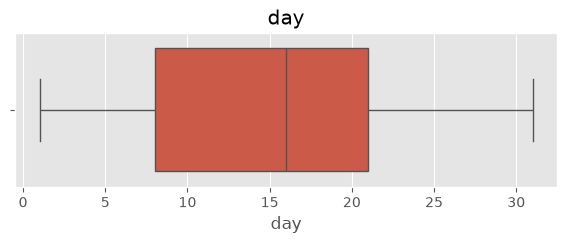

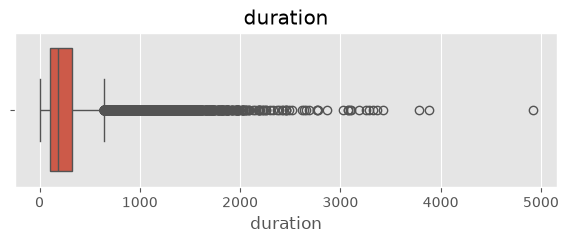

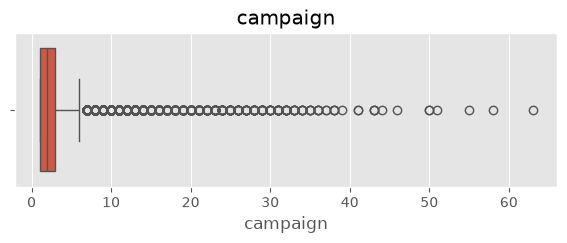

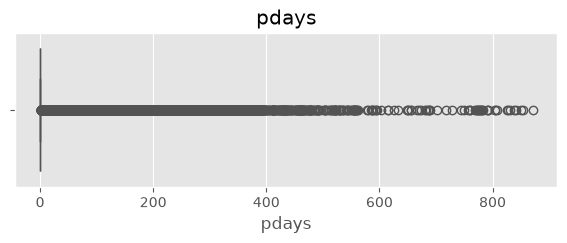

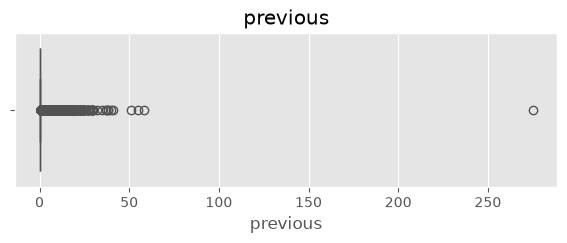

In [8]:
numerical = df.select_dtypes(include=np.number).columns
categorical = df.select_dtypes(include="object").columns.drop("y")

for col in numerical:
    plt.figure(figsize=(7,4))
    sns.histplot(df[col], kde=True)
    plt.title(col)
    plt.show()

for col in numerical:
    plt.figure(figsize=(7,2))
    sns.boxplot(x=df[col])
    plt.title(col)
    plt.show()

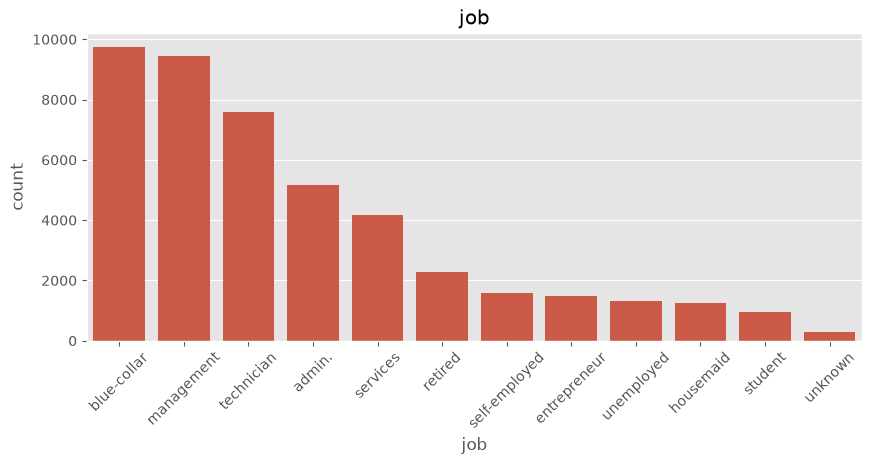

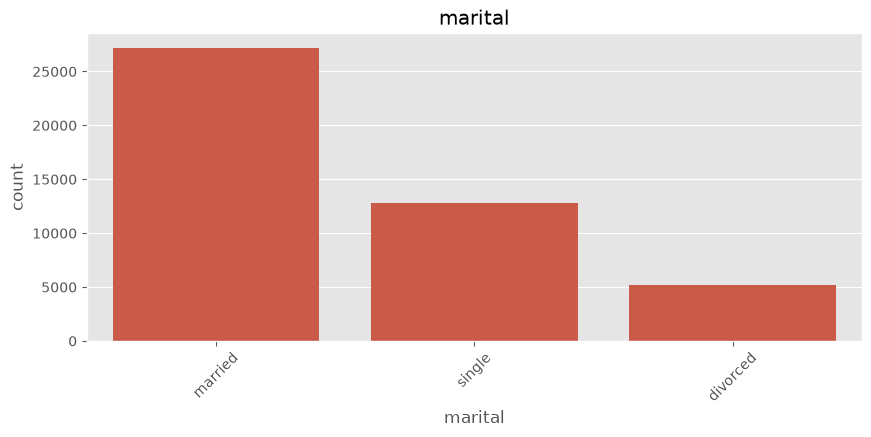

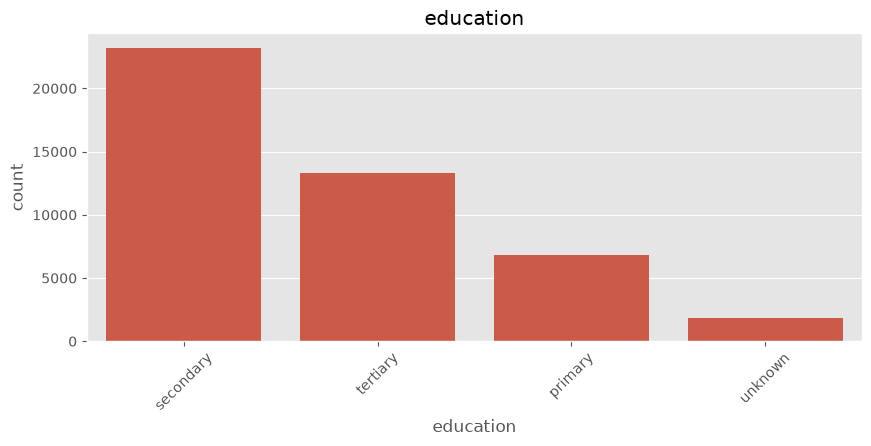

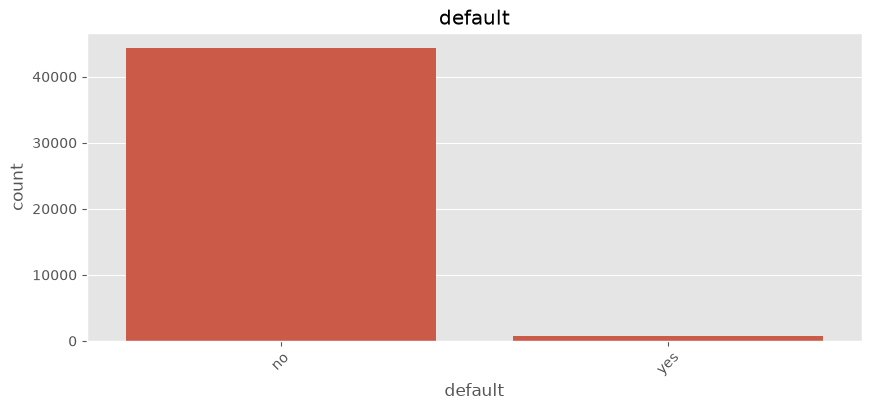

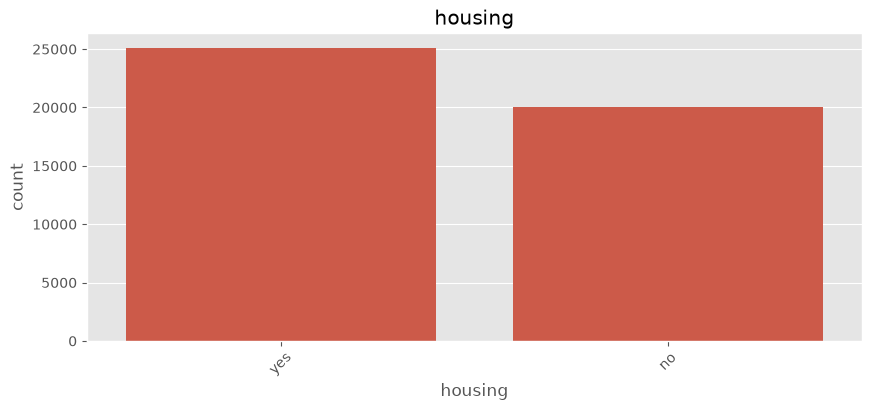

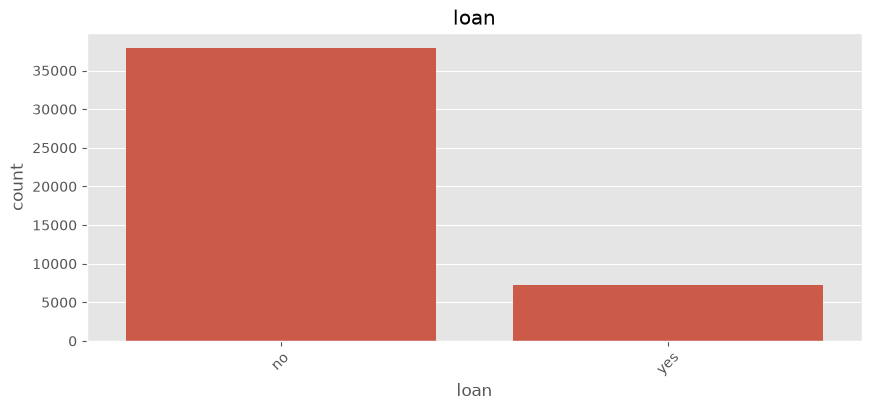

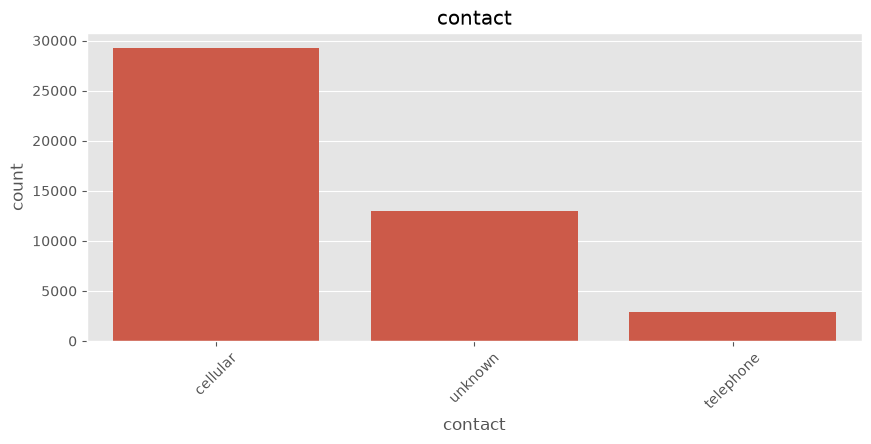

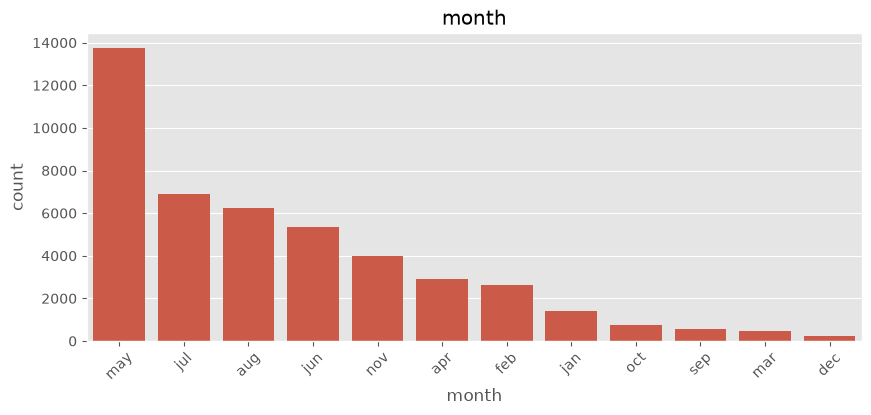

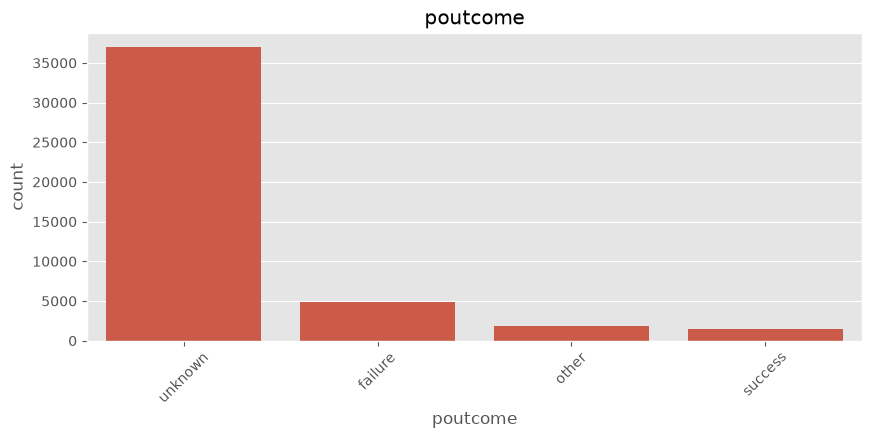

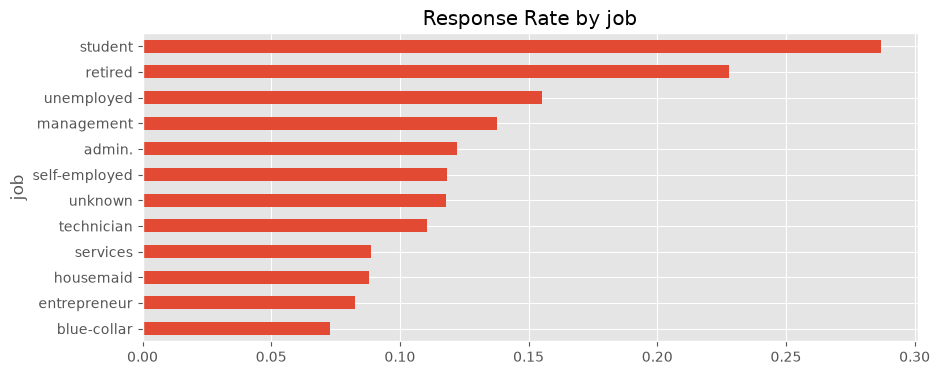

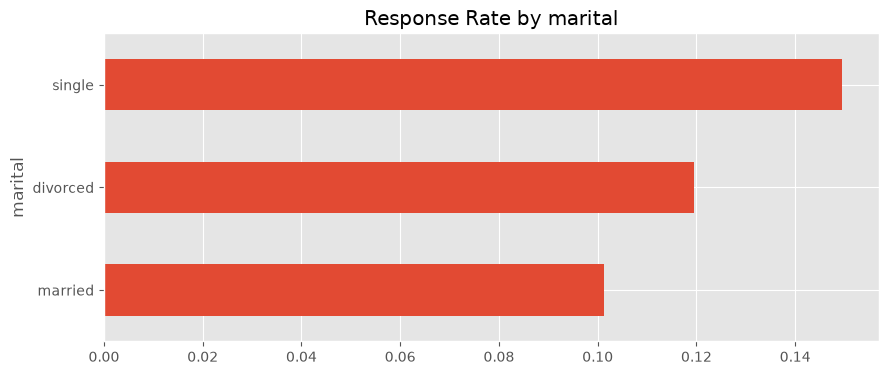

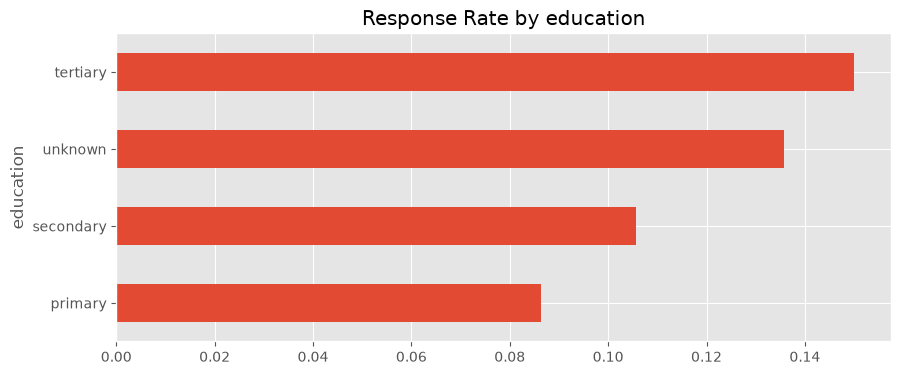

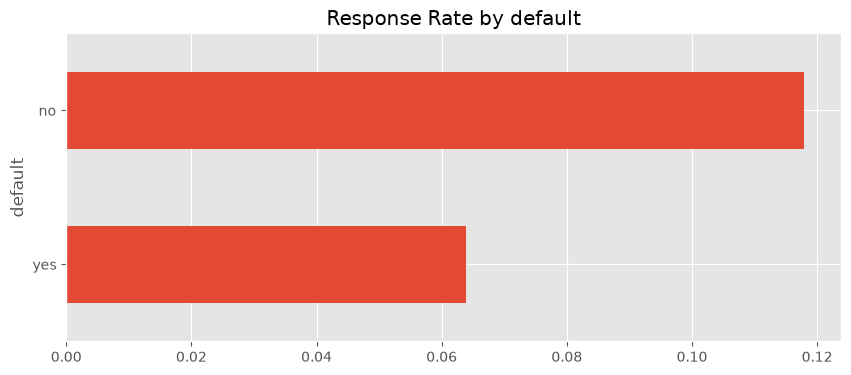

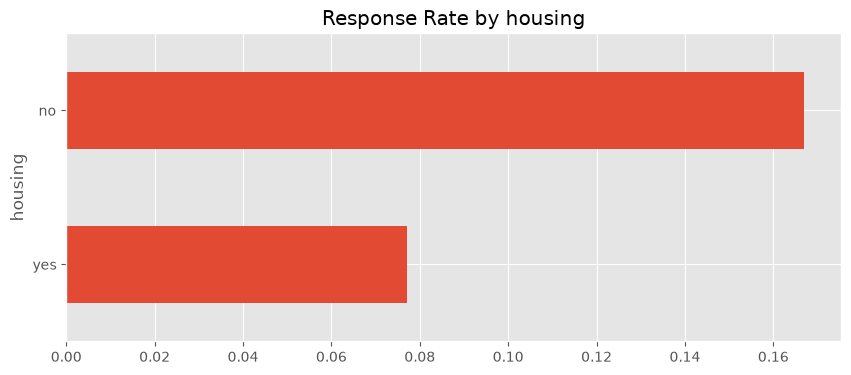

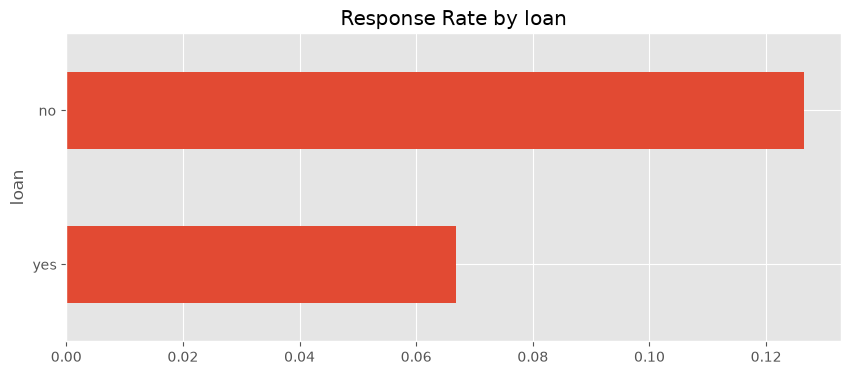

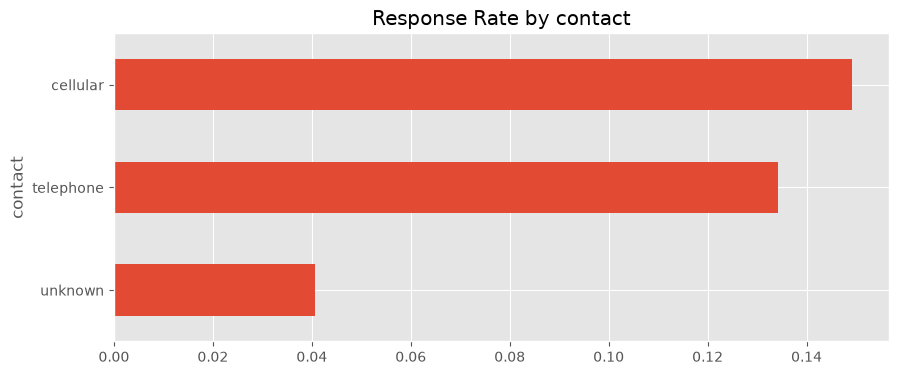

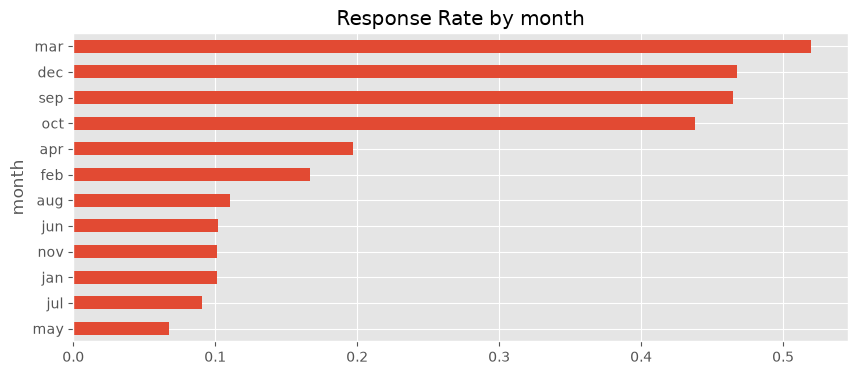

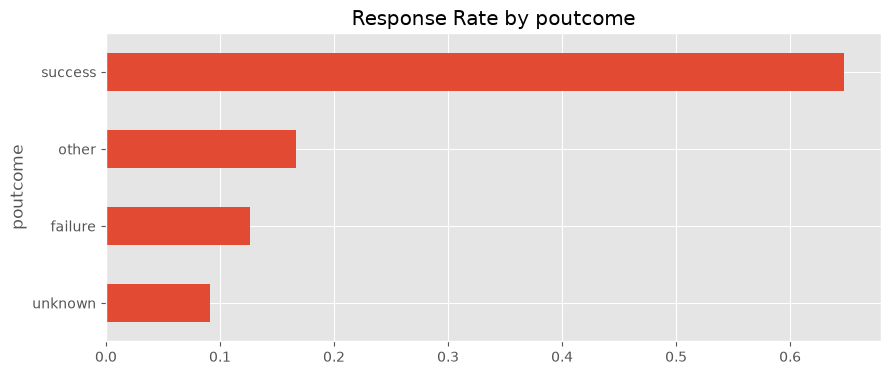

In [9]:
for col in categorical:
    plt.figure(figsize=(10,4))
    sns.countplot(data=df, x=col, order=df[col].value_counts().index)
    plt.xticks(rotation=45)
    plt.title(col)
    plt.show()

for col in categorical:
    plt.figure(figsize=(10,4))
    temp = pd.crosstab(df[col], df["y"], normalize="index")
    temp["yes"].sort_values().plot(kind="barh")
    plt.title(f"Response Rate by {col}")
    plt.show()

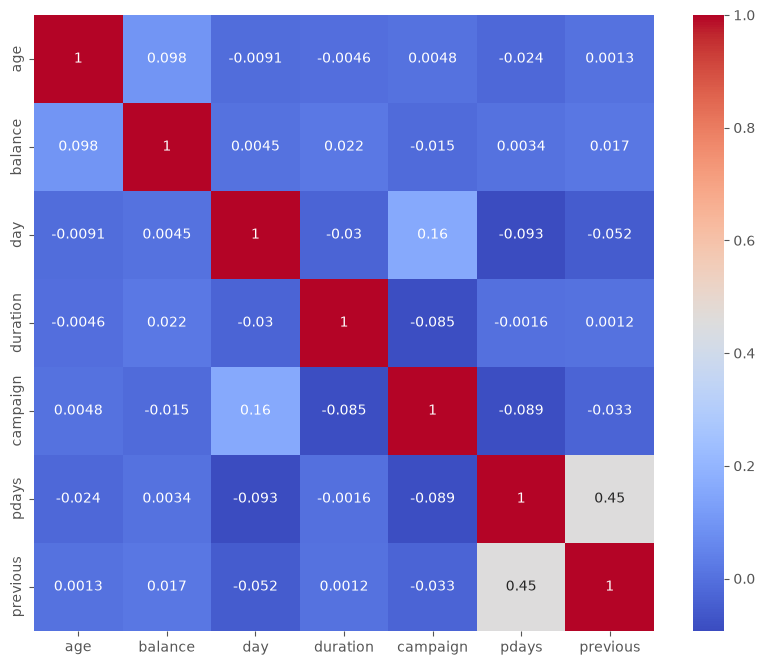

,Feature,Outliers
0,age,381
1,balance,745
2,day,0
3,duration,963
4,campaign,840
5,pdays,1723
6,previous,582


In [10]:
plt.figure(figsize=(10,8))
sns.heatmap(df[numerical].corr(), annot=True, cmap="coolwarm")
plt.show()

z_scores = np.abs(zscore(df[numerical]))
outliers = (z_scores > 3).sum(axis=0)
pd.DataFrame({"Feature": numerical, "Outliers": outliers})

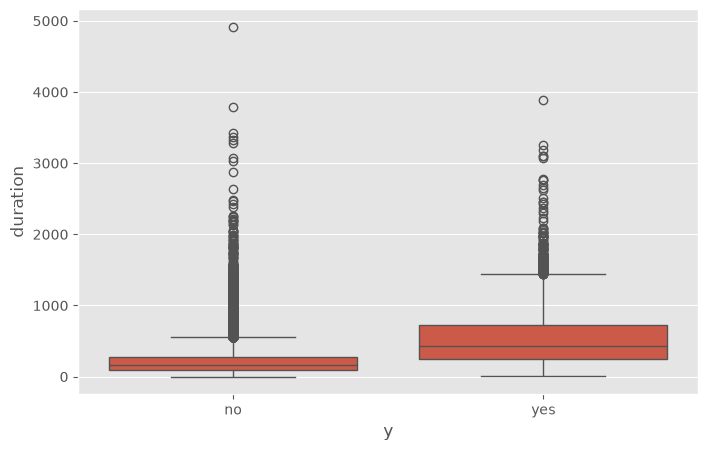

In [11]:
plt.figure(figsize=(8,5))
sns.boxplot(data=df, x="y", y="duration")
plt.show()

In [12]:
business_insights = pd.DataFrame({
    "Finding": [
        "Response rate is highly imbalanced",
        "Cellular dominates telephone contact",
        "Previous successful campaigns increase conversion",
        "Duration is a leakage variable",
        "Balance shows high variance / long right tail",
        "Campaign frequency may indicate customer fatigue",
    ]
})
business_insights

,Finding
0,Response rate is highly imbalanced
1,Cellular dominates telephone contact
2,Previous successful campaigns increase conversion
3,Duration is a leakage variable
4,Balance shows high variance / long right tail
5,Campaign frequency may indicate customer fatigue


In [13]:
# --- FIX #1: actually remove the leakage variable before saving the "clean" dataset ---
df_experimental = df.copy()               # retains `duration`, for leakage-impact analysis only
df_clean = df.drop(columns=["duration"])  # production dataset used by every downstream notebook

df_clean.to_csv("bank_clean.csv", index=False)
df_experimental.to_csv("bank_clean_experimental_with_duration.csv", index=False)
print("Saved bank_clean.csv (production, duration removed) "
      "and bank_clean_experimental_with_duration.csv (duration retained).")

Saved bank_clean.csv (production, duration removed) and bank_clean_experimental_with_duration.csv (duration retained).


## 2. Statistical Validation & Business Hypothesis Testing

Validate which features are statistically associated with the response variable (`y`)
before committing to them in feature engineering: chi-square tests for categoricals,
Welch's t-test / Mann-Whitney U for numerics (chosen per-feature via a Shapiro-Wilk
normality check), and a correlation/VIF pass for multicollinearity.

In [14]:
df = pd.read_csv("bank_clean.csv")
df["target"] = df["y"].map({"yes": 1, "no": 0})

In [15]:
cat_cols = ["job","marital","education","default","housing","loan","contact","month","poutcome"]
results = []
for c in cat_cols:
    tab = pd.crosstab(df[c], df["y"])
    chi2, p, dof, exp = chi2_contingency(tab)
    n = tab.values.sum()
    r, k = tab.shape
    cramers_v = ((chi2 / n) / min(r - 1, k - 1)) ** 0.5
    results.append([c, chi2, p, cramers_v])

res = pd.DataFrame(results, columns=["Feature","Chi2","p_value","Cramers_V"])
if HAS_SM:
    res["adj_p"] = multipletests(res.p_value, method="fdr_bh")[1]
    display(res.sort_values("adj_p"))
else:
    display(res.sort_values("p_value"))

,Feature,Chi2,p_value,Cramers_V,adj_p
7,month,3061.838938,0.000000e+00,0.260237,0.000000e+00
8,poutcome,4391.506589,0.000000e+00,0.311663,0.000000e+00
6,contact,1035.714225,1.251738e-225,0.151355,3.755215e-225
4,housing,874.822449,2.918798e-192,0.139103,6.567295e-192
0,job,836.105488,3.337122e-172,0.135990,6.006820e-172
2,education,238.923506,1.626656e-51,0.072695,2.439984e-51
5,loan,209.616980,1.665061e-47,0.068091,2.140793e-47
1,marital,196.495946,2.145100e-43,0.065926,2.413237e-43
3,default,22.202250,2.453861e-06,0.022160,2.453861e-06


In [16]:
num_cols = ["age","balance","day","campaign","pdays","previous"]
out = []
for c in num_cols:
    a = df[df.target == 1][c]
    b = df[df.target == 0][c]
    p1 = shapiro(a.sample(min(len(a), 500), random_state=RANDOM_STATE))[1]
    p2 = shapiro(b.sample(min(len(b), 500), random_state=RANDOM_STATE))[1]
    test = "Welch t-test" if (p1 > 0.05 and p2 > 0.05) else "Mann-Whitney U"
    stat, p = (ttest_ind(a, b, equal_var=False) if test == "Welch t-test"
               else mannwhitneyu(a, b))
    out.append([c, test, p, float(a.mean()), float(b.mean())])

display(pd.DataFrame(out, columns=["Feature","Test","p_value","Mean_yes","Mean_no"]))

,Feature,Test,p_value,Mean_yes,Mean_no
0,age,Mann-Whitney U,6.281791e-02,41.670070,40.838986
1,balance,Mann-Whitney U,6.593846e-101,1804.267915,1303.714969
2,day,Mann-Whitney U,3.326079e-10,15.158253,15.892290
3,campaign,Mann-Whitney U,1.948490e-71,2.141047,2.846350
4,pdays,Mann-Whitney U,2.484118e-235,68.702968,36.421372
5,previous,Mann-Whitney U,3.491824e-283,1.170354,0.502154


,age,balance,day,campaign,pdays,previous
age,1.000000,0.097783,-0.009120,0.004760,-0.023758,0.001288
balance,0.097783,1.000000,0.004503,-0.014578,0.003435,0.016674
day,-0.009120,0.004503,1.000000,0.162490,-0.093044,-0.051710
campaign,0.004760,-0.014578,0.162490,1.000000,-0.088628,-0.032855
pdays,-0.023758,0.003435,-0.093044,-0.088628,1.000000,0.454820
previous,0.001288,0.016674,-0.051710,-0.032855,0.454820,1.000000


,Feature,VIF
0,const,20.451322
1,age,1.010566
2,balance,1.010232
3,day,1.034107
4,campaign,1.033291
5,pdays,1.276045
6,previous,1.261633


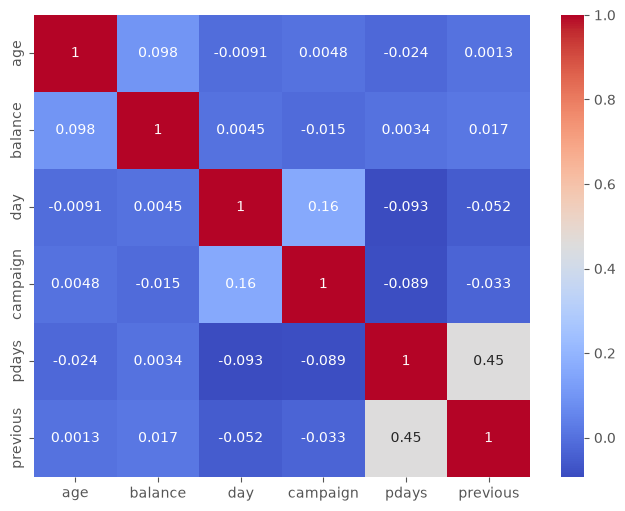

In [17]:
X = df[num_cols].fillna(0)
display(X.corr())

if HAS_SM:
    Xc = sm.add_constant(X)
    vif = pd.DataFrame({
        "Feature": Xc.columns,
        "VIF": [variance_inflation_factor(Xc.values, i) for i in range(Xc.shape[1])]
    })
    display(vif)

plt.figure(figsize=(8,6))
sns.heatmap(X.corr(), annot=True, cmap="coolwarm")
plt.show()

**Summary:** categorical predictors with the lowest adjusted p-values (after FDR
correction) and the numeric features with significant Welch/Mann-Whitney results guide
which raw variables are worth engineering further in Notebook 03. VIF values below ~5
indicate acceptable multicollinearity among the core numeric predictors.

## 3. Feature Engineering

Engineer business-driven features for customer analytics and campaign optimization:
target encoding, temporal features, binning, engagement/risk/value composites, rare-category
collapsing, and scaling.

In [18]:
df = pd.read_csv("bank_clean.csv")

df["target"] = df["y"].map({"no": 0, "yes": 1})
df.drop(columns="y", inplace=True)

month_map = {"jan":1,"feb":2,"mar":3,"apr":4,"may":5,"jun":6,
             "jul":7,"aug":8,"sep":9,"oct":10,"nov":11,"dec":12}
df["month"] = df["month"].map(month_map)

df["age_group"] = pd.cut(df.age, bins=[18,30,40,50,60,100],
                          labels=["18-30","31-40","41-50","51-60","60+"])
df["balance_band"] = pd.qcut(df.balance, q=5,
                              labels=["Very Low","Low","Medium","High","Very High"])

In [19]:
df["previous_contact"] = (df.previous > 0).astype(int)
df["previous_success"] = (df.poutcome == "success").astype(int)
df["engagement_score"] = df.previous * 2 + df.campaign - (df.pdays / 100)
df["loan_burden"] = (df.loan == "yes").astype(int) + (df.housing == "yes").astype(int)
df["financial_stability"] = (df.balance.rank(pct=True) + (1 - df.loan_burden / 2)) / 2
df["campaign_fatigue"] = df.campaign / (df.previous + 1)
df["contact_recency"] = np.where(df.pdays == -1, 999, df.pdays)

In [20]:
job_freq = df.job.value_counts()
rare = job_freq[job_freq < 500].index
df.job = df.job.replace(rare, "Other")

freq = df.job.value_counts(normalize=True)
df["job_frequency"] = df.job.map(freq)
df["balance_per_campaign"] = df.balance / (df.campaign + 1)
df["contacts_per_previous"] = df.campaign / (df.previous + 1)
df["customer_risk_score"] = ((df.default == "yes").astype(int)
                              + (df.loan == "yes").astype(int)
                              + (df.housing == "yes").astype(int))

In [21]:
le = LabelEncoder()
for c in ["education","age_group","balance_band"]:
    df[c] = le.fit_transform(df[c].astype(str))

df["log_balance"] = np.sign(df.balance) * np.log1p(np.abs(df.balance))

scaler = RobustScaler()
cols = ["balance","campaign","pdays","previous"]
df[[c + "_scaled" for c in cols]] = scaler.fit_transform(df[cols])

In [22]:
feature_summary = pd.DataFrame({"Feature": df.columns, "Data Type": df.dtypes.astype(str)})
display(feature_summary.head())

df.to_csv("bank_feature_engineered.csv", index=False)
print("Saved bank_feature_engineered.csv")

,Feature,Data Type
age,age,int64
job,job,str
marital,marital,str
education,education,int64
default,default,str


Saved bank_feature_engineered.csv


## 4. Customer Segmentation & Persona Discovery

Discover interpretable customer personas via K-Means, validated with the elbow method,
silhouette score, and a hierarchical-clustering dendrogram, then project to 2D with PCA
for visualization.

In [23]:
df = pd.read_csv("bank_feature_engineered.csv")

features = ["age","balance","job_frequency","financial_stability","customer_risk_score",
            "loan_burden","campaign_fatigue","previous_contact","previous_success"]
X = df[features].fillna(0)
scaler = RobustScaler()
Xs = scaler.fit_transform(X)

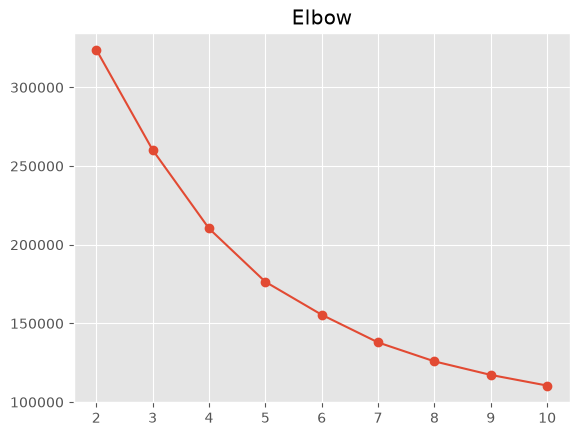

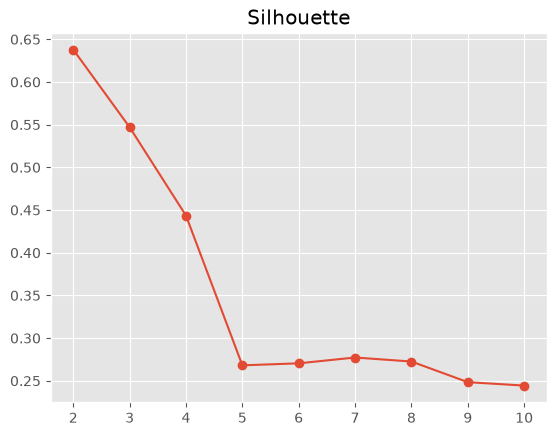

In [24]:
inertias, sil = [], []
for k in range(2, 11):
    km = KMeans(n_clusters=k, random_state=RANDOM_STATE, n_init=20)
    lbl = km.fit_predict(Xs)
    inertias.append(km.inertia_)
    sil.append(silhouette_score(Xs, lbl))

plt.plot(range(2, 11), inertias, marker="o"); plt.title("Elbow"); plt.show()
plt.plot(range(2, 11), sil, marker="o"); plt.title("Silhouette"); plt.show()

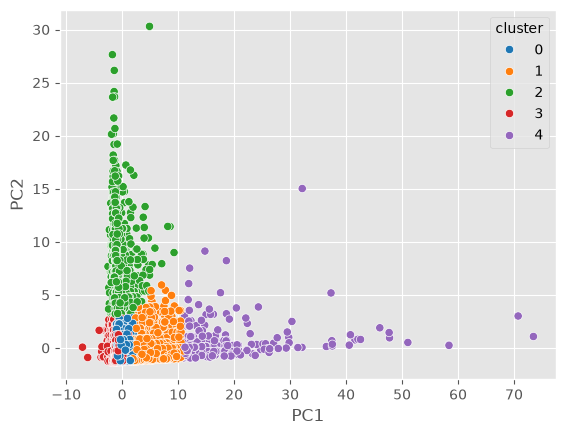

In [25]:
k = 5
km = KMeans(n_clusters=k, random_state=RANDOM_STATE, n_init=20)
df["cluster"] = km.fit_predict(Xs)

pca = PCA(n_components=2, random_state=RANDOM_STATE)
pcs = pca.fit_transform(Xs)
df["PC1"], df["PC2"] = pcs[:,0], pcs[:,1]
sns.scatterplot(data=df, x="PC1", y="PC2", hue="cluster", palette="tab10")
plt.show()

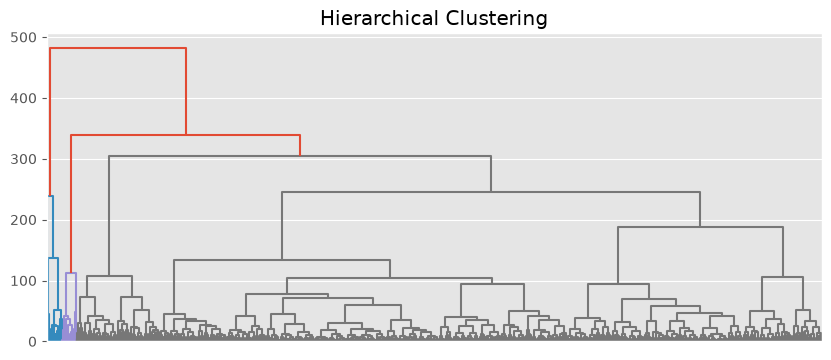

In [26]:
Z = linkage(Xs, method="ward")
plt.figure(figsize=(10,4))
dendrogram(Z, no_labels=True, color_threshold=None)
plt.title("Hierarchical Clustering")
plt.show()

In [27]:
profile = df.groupby("cluster")[features + ["target"]].mean().round(2)
display(profile)

persona = {0:"Young Professionals", 1:"Established Families", 2:"Financially Constrained",
           3:"Retirees", 4:"Emerging Professionals"}
df["persona"] = df["cluster"].map(persona).fillna("Other")

,age,balance,job_frequency,financial_stability,customer_risk_score,loan_burden,campaign_fatigue,previous_contact,previous_success,target
cluster,,,,,,,,,,
0,42.98,809.39,0.13,0.74,0.01,0.00,2.14,0.17,0.06,0.18
1,43.54,6559.09,0.15,0.83,0.57,0.57,2.04,0.22,0.05,0.16
2,40.54,837.37,0.15,0.55,0.71,0.68,14.65,0.00,0.00,0.04
3,39.30,584.12,0.15,0.43,1.19,1.16,1.97,0.20,0.02,0.08
4,45.64,25501.39,0.14,0.88,0.46,0.46,2.50,0.17,0.03,0.13


In [28]:
df["customer_value_index"] = (
    0.4 * df["financial_stability"]
    + 0.3 * (1 / (1 + df["campaign_fatigue"]))
    + 0.2 * df["previous_success"]
    + 0.1 * (2 - df["customer_risk_score"]) / 2
)

df.to_csv("bank_segmented.csv", index=False)
print("Saved bank_segmented.csv")

Saved bank_segmented.csv


> Note: `df.reset_index()` in later notebooks relies on `bank_segmented.csv`'s row
> position as the customer identifier. Row order is preserved end-to-end
> (no shuffles/sorts between Notebooks 01–04), so `customer_id = row index` is a safe,
> stable key throughout the rest of the pipeline.

## 5. Synthetic Campaign History Generation
Generate a realistic six-month interaction history per customer to support downstream
Best-Time-to-Call, Channel Affinity, and Response Propensity modeling.


In [29]:
customers = pd.read_csv("bank_segmented.csv")

channels = ["Phone","SMS","Email","WhatsApp"]
time_slots = ["Morning","Afternoon","Evening"]
start_date = pd.Timestamp("2025-01-01")
records = []

for cust_idx, row in customers.iterrows():          # FIX: renamed from `_` to `cust_idx`
    n = np.random.randint(3, 8)                      # 3-7 interactions/customer
    for _i in range(n):                              # FIX: renamed from `_` to `_i`
        dt = start_date + pd.Timedelta(days=int(np.random.randint(0, 180)))
        day_name = dt.day_name()

        # Simple business rules
        if row.get("persona", "") == "Retirees":
            slot = np.random.choice(time_slots, p=[0.55, 0.30, 0.15])
        else:
            slot = np.random.choice(time_slots, p=[0.20, 0.45, 0.35])

        if row.get("loan_burden", 0) == 2:
            channel = np.random.choice(channels, p=[0.45, 0.20, 0.15, 0.20])
        else:
            channel = np.random.choice(channels, p=[0.30, 0.25, 0.20, 0.25])

        connect_prob = 0.35 + 0.20 * row.get("previous_success", 0) + 0.10 * row.get("financial_stability", 0)
        connect = np.random.binomial(1, min(connect_prob, 0.95))

        response_prob = 0.08 + 0.25 * connect + 0.20 * row.get("previous_success", 0)
        responded = np.random.binomial(1, min(response_prob, 0.95))

        records.append({
            "customer_id": cust_idx,                 # FIX: real customer index, not inner counter
            "interaction_date": dt.date(),
            "day_of_week": day_name,
            "time_slot": slot,
            "best_time_slot": f"{day_name} {slot}",
            "channel": channel,
            "connected": connect,
            "responded": responded,
            "age": row["age"],
            "job": row["job"],
            "balance": row["balance"],
            "loan_burden": row["loan_burden"],
            "financial_stability": row["financial_stability"],
            "customer_risk_score": row["customer_risk_score"],
            "persona": row.get("persona", "Unknown"),
        })

history = pd.DataFrame(records)
print("Distinct customer_id values:", history.customer_id.nunique(), "(expected ~", len(customers), ")")
history.head()

Distinct customer_id values: 45211 (expected ~ 45211 )


,customer_id,interaction_date,day_of_week,time_slot,best_time_slot,channel,connected,responded,age,job,balance,loan_burden,financial_stability,customer_risk_score,persona
0,0,2025-05-15,Thursday,Morning,Thursday Morning,SMS,0,0,58,management,2143,1,0.661460,1,Retirees
1,0,2025-06-16,Monday,Afternoon,Monday Afternoon,Email,1,1,58,management,2143,1,0.661460,1,Retirees
2,0,2025-04-10,Thursday,Morning,Thursday Morning,WhatsApp,0,1,58,management,2143,1,0.661460,1,Retirees
3,0,2025-04-10,Thursday,Morning,Thursday Morning,Email,1,0,58,management,2143,1,0.661460,1,Retirees
4,1,2025-01-29,Wednesday,Morning,Wednesday Morning,WhatsApp,0,0,44,technician,29,1,0.354095,1,Retirees


In [30]:
print(history.shape)
print(history["responded"].value_counts(normalize=True))
print(history["channel"].value_counts())
print(history["best_time_slot"].value_counts().head())

(225951, 15)
responded
0    0.81107
1    0.18893
Name: proportion, dtype: float64
channel
Phone       71182
WhatsApp    55380
SMS         55330
Email       44059
Name: count, dtype: int64
best_time_slot
Saturday Morning     12829
Friday Morning       12797
Wednesday Morning    12772
Thursday Morning     12725
Sunday Morning       12544
Name: count, dtype: int64


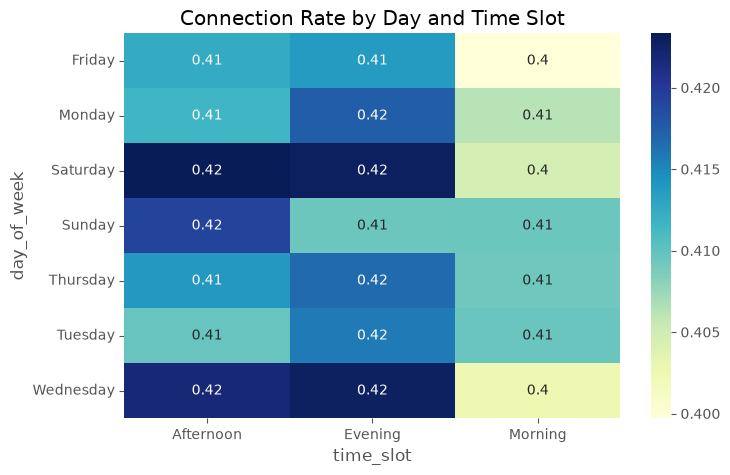

In [31]:
pivot = history.pivot_table(index="day_of_week", columns="time_slot",
                             values="connected", aggfunc="mean")
plt.figure(figsize=(8,5))
sns.heatmap(pivot, annot=True, cmap="YlGnBu")
plt.title("Connection Rate by Day and Time Slot")
plt.show()

In [32]:
channel_cost = {"Phone": 10, "SMS": 0.30, "Email": 0.05, "WhatsApp": 0.60}
history["channel_cost"] = history["channel"].map(channel_cost)

history.to_csv("synthetic_campaign_history.csv", index=False)
print("Saved synthetic_campaign_history.csv")

Saved synthetic_campaign_history.csv


**Business Notes**
- Each customer receives 3–7 simulated interactions over six months.
- Interaction probabilities depend on customer profile and previous campaign success.
- The generated dataset supports Best Time-to-Call modeling, Channel Affinity modeling,
  Response Propensity modeling, and campaign cost optimization.

## 6. Best Time-to-Call Model

Predict the best `day_of_week × time_slot` combination to contact an *existing* customer,
using their profile plus historical interaction outcomes. This is the supervised
counterpart to the Look-Alike (cold-start) model in Part 7, which handles customers with
no interaction history at all.

In [33]:
history = pd.read_csv("synthetic_campaign_history.csv")

# Aggregate to one row per customer: their most frequent best_time_slot plus profile features
best_slot = (history.groupby("customer_id")["best_time_slot"]
             .agg(lambda x: x.value_counts().idxmax())
             .reset_index())

customers = pd.read_csv("bank_segmented.csv").reset_index().rename(columns={"index": "customer_id"})
data = customers.merge(best_slot, on="customer_id", how="inner")

btc_features = ["age","job","marital","education","balance","loan_burden",
                "financial_stability","customer_risk_score","persona"]
X = data[btc_features]
y = data["best_time_slot"]

cat = X.select_dtypes(include="object").columns.tolist()
num = X.select_dtypes(exclude="object").columns.tolist()
pre = ColumnTransformer([("cat", OneHotEncoder(handle_unknown="ignore"), cat),
                          ("num", "passthrough", num)])

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_STATE, stratify=y)

In [34]:
results = []
fitted = {}

rf_pipe = Pipeline([("prep", pre), ("model", RandomForestClassifier(n_estimators=300, random_state=RANDOM_STATE))])
rf_pipe.fit(X_train, y_train)
pred = rf_pipe.predict(X_test)
results.append(["RandomForest", accuracy_score(y_test, pred), f1_score(y_test, pred, average="macro")])
fitted["RandomForest"] = rf_pipe

if HAS_LGB:
    lgb_pipe = Pipeline([("prep", pre), ("model", lgb.LGBMClassifier(random_state=RANDOM_STATE))])
    lgb_pipe.fit(X_train, y_train)
    pred = lgb_pipe.predict(X_test)
    results.append(["LightGBM", accuracy_score(y_test, pred), f1_score(y_test, pred, average="macro")])
    fitted["LightGBM"] = lgb_pipe

if HAS_XGB:
    Xtr_enc = pre.fit_transform(X_train)
    Xte_enc = pre.transform(X_test)
    xgb_model, xgb_le = fit_xgb_multiclass(Xtr_enc, y_train)
    pred = predict_xgb_multiclass(xgb_model, xgb_le, Xte_enc)
    results.append(["XGBoost", accuracy_score(y_test, pred), f1_score(y_test, pred, average="macro")])
    fitted["XGBoost"] = (pre, xgb_model, xgb_le)

results_df = pd.DataFrame(results, columns=["Model","Accuracy","Macro_F1"])
print(results_df)
best_name = results_df.sort_values("Macro_F1", ascending=False).iloc[0]["Model"]
print("Best model:", best_name)

[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000997 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 636
[LightGBM] [Info] Number of data points in the train set: 36168, number of used features: 26
[LightGBM] [Info] Start training from score -2.954778
[LightGBM] [Info] Start training from score -3.412542
[LightGBM] [Info] Start training from score -2.839120
[LightGBM] [Info] Start training from score -2.958500
[LightGBM] [Info] Start training from score -3.553773
[LightGBM] [Info] Start training from score -2.868873
[LightGBM] [Info] Start training from score -2.904068
[LightGBM] [Info] Start training from score -3.422660
[LightGBM] [Info] Start training from score -2.796088
[LightGBM] [Info] Start training from score -2.920858
[LightGBM] [Info] Start training from score -3.441480
[LightGBM] [Info] Start training from score -2.859660


In [35]:
# Apply the best model to score every existing customer's preferred contact window
if best_name == "XGBoost":
    prep_fitted, xgb_model, xgb_le = fitted["XGBoost"]
    data["predicted_best_time_slot"] = predict_xgb_multiclass(xgb_model, xgb_le, prep_fitted.transform(X))
else:
    data["predicted_best_time_slot"] = fitted[best_name].predict(X)

data[["customer_id","predicted_best_time_slot"]].to_csv("best_time_to_call_predictions.csv", index=False)
print("Saved best_time_to_call_predictions.csv")

Saved best_time_to_call_predictions.csv


**Business Outcome:** for every customer with interaction history, the model recommends
a specific day-of-week × time-slot window that historically maximizes connection
likelihood, feeding directly into the campaign scheduling layer alongside the channel and
response-propensity outputs from Part 8.

## 7. Look-Alike Model (Cold Start)

Predict the best contact time for customers with **little or no historical interaction**,
using only static profile features (no `best_time_slot` history required). This is the
cold-start counterpart to Part 6.

In [36]:
history = pd.read_csv("synthetic_campaign_history.csv")
customers = pd.read_csv("bank_segmented.csv").reset_index().rename(columns={"index": "customer_id"})

hist_summary = (history.groupby("customer_id")["best_time_slot"]
                .agg(lambda x: x.value_counts().idxmax())
                .reset_index())
data = customers.merge(hist_summary, on="customer_id", how="left")

train = data[data["best_time_slot"].notna()].copy()
cold = data[data["best_time_slot"].isna()].copy()
print("Customers with history:", len(train), "| True cold-start customers:", len(cold))

la_features = ["age","job","marital","education","balance","loan_burden",
               "financial_stability","customer_risk_score","persona"]

Customers with history: 45211 | True cold-start customers: 0


In [37]:
# Hold out a slice of customers and pretend they are cold (profile-only) to validate the approach
train_fit, train_holdout = train_test_split(train, test_size=0.15, random_state=RANDOM_STATE,
                                             stratify=train["best_time_slot"])

X = train_fit[la_features]
y = train_fit["best_time_slot"]
cat = X.select_dtypes(include="object").columns.tolist()
num = X.select_dtypes(exclude="object").columns.tolist()
pre = ColumnTransformer([("cat", OneHotEncoder(handle_unknown="ignore"), cat),
                          ("num", "passthrough", num)])

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, stratify=y, random_state=RANDOM_STATE)

In [38]:
results = []
fitted = {}

rf_pipe = Pipeline([("prep", pre), ("model", RandomForestClassifier(n_estimators=300, random_state=RANDOM_STATE))])
rf_pipe.fit(X_train, y_train)
pred = rf_pipe.predict(X_test)
results.append(["RandomForest", accuracy_score(y_test, pred), f1_score(y_test, pred, average="macro")])
fitted["RandomForest"] = rf_pipe

if HAS_LGB:
    lgb_pipe = Pipeline([("prep", pre), ("model", lgb.LGBMClassifier(random_state=RANDOM_STATE))])
    lgb_pipe.fit(X_train, y_train)
    pred = lgb_pipe.predict(X_test)
    results.append(["LightGBM", accuracy_score(y_test, pred), f1_score(y_test, pred, average="macro")])
    fitted["LightGBM"] = lgb_pipe

if HAS_XGB:
    Xtr_enc = pre.fit_transform(X_train)
    Xte_enc = pre.transform(X_test)
    xgb_model, xgb_le = fit_xgb_multiclass(Xtr_enc, y_train)
    pred = predict_xgb_multiclass(xgb_model, xgb_le, Xte_enc)
    results.append(["XGBoost", accuracy_score(y_test, pred), f1_score(y_test, pred, average="macro")])
    fitted["XGBoost"] = (pre, xgb_model, xgb_le)

results_df = pd.DataFrame(results, columns=["Model","Accuracy","Macro_F1"])
print(results_df)
best_name = results_df.sort_values("Macro_F1", ascending=False).iloc[0]["Model"]
print("Best model:", best_name)

[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000241 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 635
[LightGBM] [Info] Number of data points in the train set: 30743, number of used features: 26
[LightGBM] [Info] Start training from score -2.955034
[LightGBM] [Info] Start training from score -3.411759
[LightGBM] [Info] Start training from score -2.839544
[LightGBM] [Info] Start training from score -2.958789
[LightGBM] [Info] Start training from score -3.553496
[LightGBM] [Info] Start training from score -2.868908
[LightGBM] [Info] Start training from score -2.903897
[LightGBM] [Info] Start training from score -3.422667
[LightGBM] [Info] Start training from score -2.795988
[LightGBM] [Info] Start training from score -2.920654
[LightGBM] [Info] Start training from score -3.440776
[LightGBM] [Info] Start training from score -2.859780


In [39]:
# Score the held-out ("pretend cold") customers plus any genuinely cold customers, profile-only
score_targets = pd.concat([train_holdout, cold], ignore_index=True) if len(cold) else train_holdout

if best_name == "XGBoost":
    prep_fitted, xgb_model, xgb_le = fitted["XGBoost"]
    score_targets["predicted_best_time_slot"] = predict_xgb_multiclass(
        xgb_model, xgb_le, prep_fitted.transform(score_targets[la_features]))
else:
    score_targets["predicted_best_time_slot"] = fitted[best_name].predict(score_targets[la_features])

score_targets[["customer_id","predicted_best_time_slot"]].to_csv("lookalike_predictions.csv", index=False)
print("Saved lookalike_predictions.csv for", len(score_targets), "cold/pretend-cold customers")

Saved lookalike_predictions.csv for 6782 cold/pretend-cold customers


**Business Outcome:** this notebook addresses the cold-start problem by recommending an
initial best contact slot from customer profile features alone, for customers where no
interaction history yet exists (e.g., newly onboarded customers).

## 8. Channel Affinity & Response Propensity Models

Two production use cases:
1. Predict the **best communication channel** (Phone, SMS, Email, WhatsApp).
2. Predict the **probability that a customer will respond** to the campaign.

In [40]:
history = pd.read_csv("synthetic_campaign_history.csv")

channel_features = ["age","job","balance","loan_burden","financial_stability",
                     "customer_risk_score","persona","day_of_week","time_slot"]
X = history[channel_features]
y = history["channel"]

cat = X.select_dtypes(include="object").columns.tolist()
num = X.select_dtypes(exclude="object").columns.tolist()
pre = ColumnTransformer([("cat", OneHotEncoder(handle_unknown="ignore"), cat),
                          ("num", "passthrough", num)])

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=RANDOM_STATE, stratify=y)

In [41]:
results = []
best_f1, best_channel_model, best_channel_name = -1, None, None
fitted_channel = {}

rf_pipe = Pipeline([("prep", pre), ("model", RandomForestClassifier(n_estimators=300, random_state=RANDOM_STATE))])
rf_pipe.fit(X_train, y_train)
pred = rf_pipe.predict(X_test)
f1 = f1_score(y_test, pred, average="macro")
results.append(["Random Forest", accuracy_score(y_test, pred), f1])
fitted_channel["Random Forest"] = rf_pipe
if f1 > best_f1: best_f1, best_channel_model, best_channel_name = f1, rf_pipe, "Random Forest"

if HAS_LGB:
    lgb_pipe = Pipeline([("prep", pre), ("model", lgb.LGBMClassifier(random_state=RANDOM_STATE))])
    lgb_pipe.fit(X_train, y_train)
    pred = lgb_pipe.predict(X_test)
    f1 = f1_score(y_test, pred, average="macro")
    results.append(["LightGBM", accuracy_score(y_test, pred), f1])
    fitted_channel["LightGBM"] = lgb_pipe
    if f1 > best_f1: best_f1, best_channel_model, best_channel_name = f1, lgb_pipe, "LightGBM"

if HAS_XGB:
    Xtr_enc = pre.fit_transform(X_train)
    Xte_enc = pre.transform(X_test)
    xgb_model, xgb_le = fit_xgb_multiclass(Xtr_enc, y_train)
    pred = predict_xgb_multiclass(xgb_model, xgb_le, Xte_enc)
    f1 = f1_score(y_test, pred, average="macro")
    results.append(["XGBoost", accuracy_score(y_test, pred), f1])
    fitted_channel["XGBoost"] = (pre, xgb_model, xgb_le)
    if f1 > best_f1: best_f1, best_channel_model, best_channel_name = f1, ("XGBoost"), "XGBoost"

print(pd.DataFrame(results, columns=["Model","Accuracy","Macro_F1"]))
print("Best channel model:", best_channel_name)

[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.002026 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 649
[LightGBM] [Info] Number of data points in the train set: 180760, number of used features: 32
[LightGBM] [Info] Start training from score -1.634790
[LightGBM] [Info] Start training from score -1.155084
[LightGBM] [Info] Start training from score -1.406998
[LightGBM] [Info] Start training from score -1.406095
           Model  Accuracy  Macro_F1
0  Random Forest  0.265827  0.252698
1       LightGBM  0.311943  0.142500
2        XGBoost  0.306676  0.181903
Best channel model: Random Forest


### Part B — Response Propensity Model

In [44]:
target = "responded"
response_features = ["age","job","balance","loan_burden","financial_stability",
                      "customer_risk_score","persona","channel","day_of_week","time_slot","connected"]

X = history[response_features]
y = history[target]

cat = X.select_dtypes(include="object").columns.tolist()
num = X.select_dtypes(exclude="object").columns.tolist()
pre_resp = ColumnTransformer([("cat", OneHotEncoder(handle_unknown="ignore"), cat),
                               ("num", "passthrough", num)])

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=RANDOM_STATE, stratify=y)

In [46]:
import time

summary = []
best_auc, best_response_model, best_response_name = -1, None, None
fitted_response = {}

def _fit_and_score(name, pipe):
    t0 = time.time()
    pipe.fit(X_train, y_train)
    pred = pipe.predict(X_test)
    proba = pipe.predict_proba(X_test)[:, 1]
    auc = roc_auc_score(y_test, proba)
    elapsed = time.time() - t0
    print(f"{name}: fit+eval took {elapsed:.1f}s")
    summary.append([name, accuracy_score(y_test, pred), f1_score(y_test, pred), auc])
    fitted_response[name] = pipe
    return pipe, auc

lr_pipe = Pipeline([("prep", pre_resp), ("model", LogisticRegression(max_iter=2000, n_jobs=-1))])
lr_pipe, auc = _fit_and_score("Logistic Regression", lr_pipe)
if auc > best_auc:
    best_auc, best_response_model, best_response_name = auc, lr_pipe, "Logistic Regression"

rf_pipe = Pipeline([("prep", pre_resp), ("model", RandomForestClassifier(
    n_estimators=300,
    max_depth=20,      # cap depth - unbounded trees on continuous features (balance, age) are the #1 cause of hangs
    n_jobs=-1,          # use all cores instead of the single-core default
    random_state=RANDOM_STATE,
))])
rf_pipe, auc = _fit_and_score("Random Forest", rf_pipe)
if auc > best_auc:
    best_auc, best_response_model, best_response_name = auc, rf_pipe, "Random Forest"

if HAS_LGB:
    lgb_pipe = Pipeline([("prep", pre_resp), ("model", lgb.LGBMClassifier(
        random_state=RANDOM_STATE, n_jobs=-1
    ))])
    lgb_pipe, auc = _fit_and_score("LightGBM", lgb_pipe)
    if auc > best_auc:
        best_auc, best_response_model, best_response_name = auc, lgb_pipe, "LightGBM"

if HAS_XGB:
    xgb_pipe = Pipeline([("prep", pre_resp), ("model", XGBClassifier(
        eval_metric="logloss", random_state=RANDOM_STATE, n_jobs=-1
    ))])
    xgb_pipe, auc = _fit_and_score("XGBoost", xgb_pipe)   # binary target -> no label-encoder wrapper needed
    if auc > best_auc:
        best_auc, best_response_model, best_response_name = auc, xgb_pipe, "XGBoost"

print(pd.DataFrame(summary, columns=["Model", "Accuracy", "F1", "ROC_AUC"]))
print("Best response model:", best_response_name)

Logistic Regression: fit+eval took 19.9s
Random Forest: fit+eval took 95.9s
[LightGBM] [Info] Number of positive: 34151, number of negative: 146609
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.002035 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 659
[LightGBM] [Info] Number of data points in the train set: 180760, number of used features: 37
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.188930 -> initscore=-1.456977
[LightGBM] [Info] Start training from score -1.456977
LightGBM: fit+eval took 0.8s
XGBoost: fit+eval took 1.0s
                 Model  Accuracy        F1   ROC_AUC
0  Logistic Regression  0.811069  0.000000  0.705094
1        Random Forest  0.809276  0.019565  0.702605
2             LightGBM  0.810582  0.002098  0.704836
3              XGBoost  0.809077  0.024864  0.699567
Best response model: Logistic Regression


In [47]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
cv_score = cross_val_score(best_response_model, X, y, cv=cv, scoring="roc_auc")
print("Mean CV ROC-AUC:", cv_score.mean())

recommendations = history.copy()

if best_channel_name == "XGBoost":
    prep_fitted, xgb_model, xgb_le = fitted_channel["XGBoost"]
    recommendations["predicted_channel"] = predict_xgb_multiclass(
        xgb_model, xgb_le, prep_fitted.transform(history[channel_features]))
else:
    recommendations["predicted_channel"] = fitted_channel[best_channel_name].predict(history[channel_features])

recommendations["response_probability"] = best_response_model.predict_proba(history[response_features])[:,1]

recommendations[["customer_id","predicted_channel","response_probability"]].to_csv(
    "customer_campaign_recommendations.csv", index=False)
print("Saved customer_campaign_recommendations.csv")

Mean CV ROC-AUC: 0.7048213393946504
Saved customer_campaign_recommendations.csv


**Business Deliverables:** preferred communication channel and estimated response
probability for every customer/interaction row — the combined recommendation dataset
feeding the marketing campaign scheduling layer. This completes the predictive modeling
phase of the project.

## 9. Executive Business Report

## Intelligent Customer Contact Optimization System

### 9.1 Project Overview
This project developed an end-to-end customer contact optimization framework:
data quality assessment → statistical validation → feature engineering → customer
segmentation → synthetic campaign history generation → best time-to-call prediction →
look-alike modeling → channel affinity prediction → response propensity prediction —
aiming to maximize campaign effectiveness while minimizing communication cost.

In [48]:
customers = pd.read_csv("bank_segmented.csv")
history = pd.read_csv("synthetic_campaign_history.csv")
recommendations = pd.read_csv("customer_campaign_recommendations.csv")

print("Customers:", customers.shape)
print("Interactions:", history.shape)
print("Recommendations:", recommendations.shape)
print("Distinct customers with interactions:", history.customer_id.nunique())

Customers: (45211, 39)
Interactions: (225951, 16)
Recommendations: (225951, 3)
Distinct customers with interactions: 45211


### 9.2 Dataset Summary

In [49]:
print(customers["persona"].value_counts())
print(history["channel"].value_counts())
print(history["best_time_slot"].value_counts().head(10))

persona
Retirees                   24802
Young Professionals        14445
Established Families        3984
Financially Constrained     1671
Emerging Professionals       309
Name: count, dtype: int64
channel
Phone       71182
WhatsApp    55380
SMS         55330
Email       44059
Name: count, dtype: int64
best_time_slot
Saturday Morning      12829
Friday Morning        12797
Wednesday Morning     12772
Thursday Morning      12725
Sunday Morning        12544
Monday Morning        12407
Tuesday Morning       12281
Sunday Afternoon      12200
Thursday Afternoon    12132
Saturday Afternoon    12097
Name: count, dtype: int64


### 9.4 Customer Personas
- Young Professionals
- Established Families
- Emerging Professionals
- Financially Constrained
- Retirees

These personas provide interpretable marketing segments for campaign targeting.